In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 18359, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 18359 (delta 33), reused 16 (delta 16), pack-reused 18307 (from 2)
Receiving objects: 100% (18359/18359), 17.46 MiB | 18.88 MiB/s, done.
Resolving deltas: 100% (12478/12478), done.
/content/yolov5/yolov5


In [ ]:
!pip install -q roboflow

In [ ]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("2026-oss").project("ai-picture-book-object-detection")
dataset = project.version(4).download("yolov5")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov5pytorch in progress : 91.0%
Version export complete for yolov5pytorch format



Extracting Dataset Version Zip to AI-Picture-Book-Object-Detection-3 in yolov5pytorch:: 100%|██████████| 3817/3817 [00:00<00:00, 7089.97it/s]


In [ ]:
!ls

AI-Picture-Book-Object-Detection-3  export.py	     requirements.txt
benchmarks.py			    hubconf.py	     segment
CITATION.cff			    LICENSE	     tests
classify			    models	     train.py
CONTRIBUTING.md			    pyproject.toml   tutorial.ipynb
data				    README.md	     utils
detect.py			    README.zh-CN.md  val.py


In [ ]:
!find . -name "data.yaml"

./AI-Picture-Book-Object-Detection-3/data.yaml


In [ ]:
!ls AI-Picture-Book-Object-Detection-4

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
yaml_path = "./AI-Picture-Book-Object-Detection-4/data.yaml"

with open(yaml_path, "r") as f:
    data = f.read()

data = data.replace("train: train/images", "train: ./AI-Picture-Book-Object-Detection-4/train/images")
data = data.replace("val: valid/images", "val: ./AI-Picture-Book-Object-Detection-4/valid/images")
data = data.replace("test: test/images", "test: ./AI-Picture-Book-Object-Detection-4/test/images")

with open(yaml_path, "w") as f:
    f.write(data)

!cat ./AI-Picture-Book-Object-Detection-4/data.yaml

names:
- book_flower
- book_flowerpot
- book_monkey
- book_stone
- braille
- tactile_flower
- tactile_flowerpot
- tactile_monkey
- tactile_stone
- text
nc: 10
roboflow:
  license: MIT
  project: ai-picture-book-object-detection
  url: https://universe.roboflow.com/2026-oss/ai-picture-book-object-detection/dataset/3
  version: 3
  workspace: 2026-oss
test: ../test/images
train: AI-Picture-Book-Object-Detection-3/train/images
val: AI-Picture-Book-Object-Detection-3/valid/images


In [ ]:
!ls AI-Picture-Book-Object-Detection-4/train/images | head
!ls AI-Picture-Book-Object-Detection-4/valid/images | head
!ls AI-Picture-Book-Object-Detection-4/test/images | head

ls: cannot access 'AI-Picture-Book-Object-Detection-2/train/images': No such file or directory
ls: cannot access 'AI-Picture-Book-Object-Detection-2/valid/images': No such file or directory
ls: cannot access 'AI-Picture-Book-Object-Detection-2/test/images': No such file or directory


In [ ]:
!nvidia-smi

Mon Jun 15 03:12:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!wget https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt

--2026-06-15 03:12:57--  https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/381bd8a8-8910-4e9e-b0dd-2752951ef78c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-15T04%3A01%3A08Z&rscd=attachment%3B+filename%3Dyolov5s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-15T03%3A01%3A00Z&ske=2026-06-15T04%3A01%3A08Z&sks=b&skv=2018-11-09&sig=6L714L%2BWq5dFlZTZ57pkpoKVHyVAn0Vh9H%2BMd0TTiXs%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTQ5NDk3OCwibmJmIjoxNzgxNDkzMTc4LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

In [ ]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 100 \
--data ./AI-Picture-Book-Object-Detection-4/data.yaml \
--weights yolov5s.pt \
--name picture_book_yolov5

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  with torch.cuda.amp.autocast(amp):
      78/99      4.37G     0.0203   0.008186  0.0007683         40        640:  62% 71/114 [00:28<00:15,  2.75it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      78/99      4.37G    0.02034   0.008165  0.0007653         32        640:  63% 72/114 [00:29<00:15,  2.72it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      78/99      4.37G    0.02032    0.00814  0.0007616         28        640:  64% 73/114 [00:29<00:15,  2.69it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autoca

In [ ]:
!ls runs/train

picture_book_yolov5


Best weights: runs/train/picture_book_yolov5/weights/best.pt
detect: weights=['runs/train/picture_book_yolov5/weights/best.pt'], source=./AI-Picture-Book-Object-Detection-3/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7037095 parameters, 0 gradients, 15.8 GFLOPs
image 1/28 /content/yolov5/yolov5/AI-Picture-Book-Object-Detection-3/test/images/book_flowerpot_0001_jpeg.rf.bd70f4fbdee01021e3ae1d7a7ecc9374.jpg: 640x640 1 book_flowerpot, 10.0ms
image 2/28 /content/yolov5/

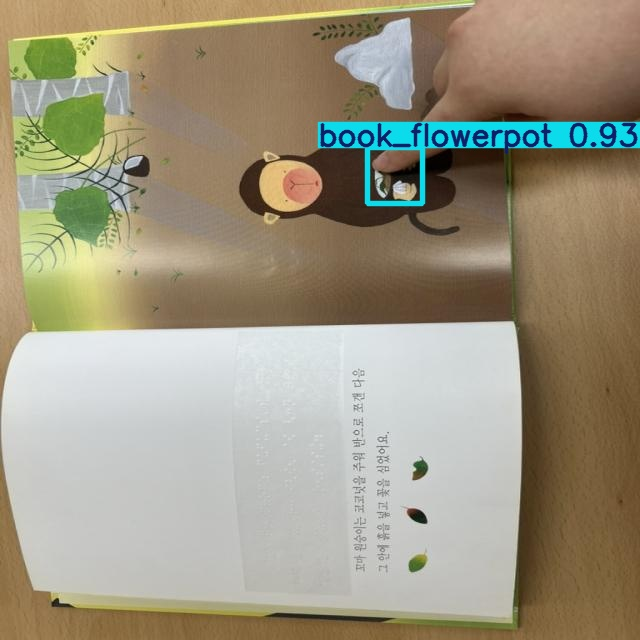

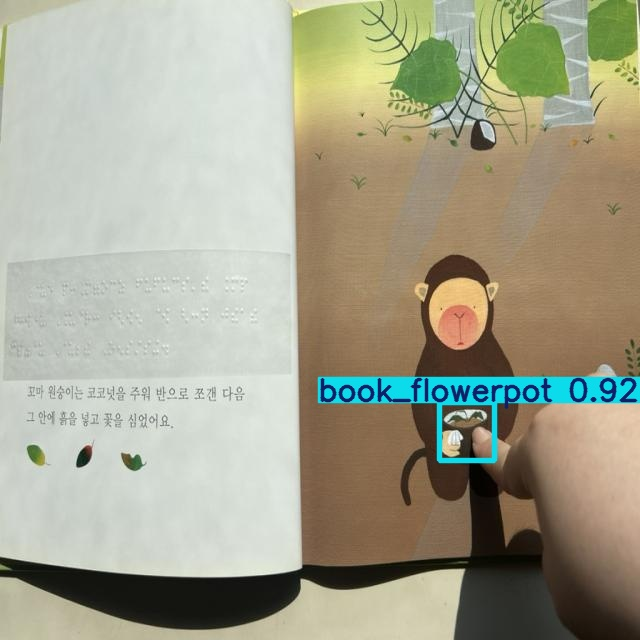

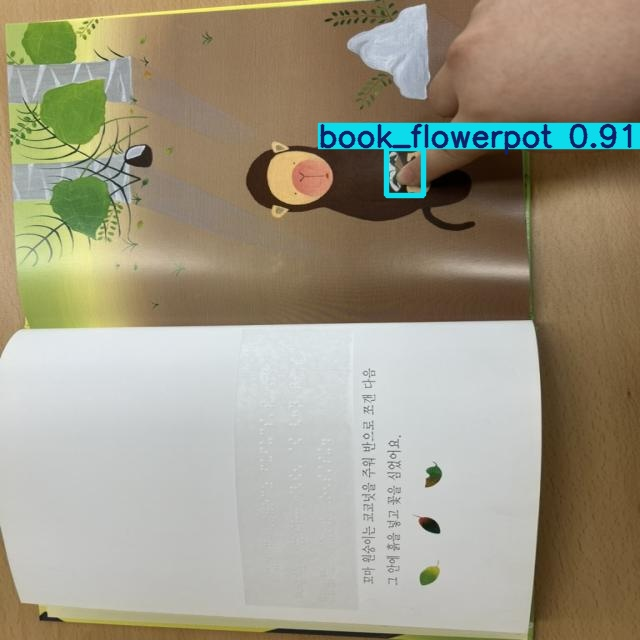

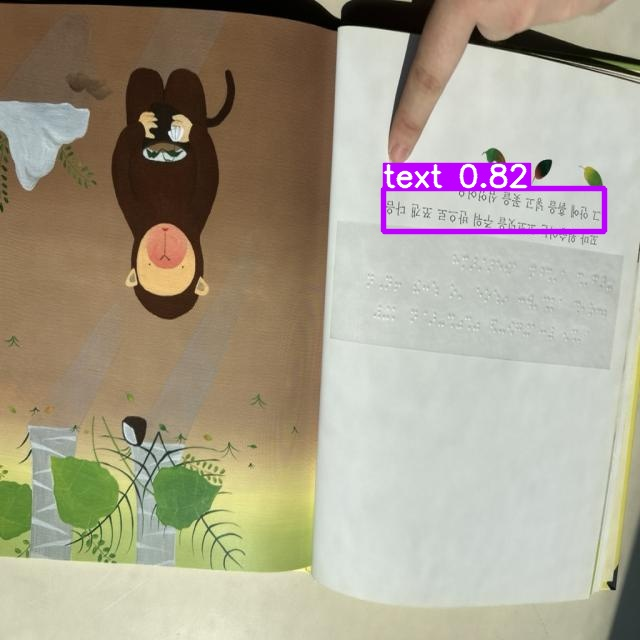

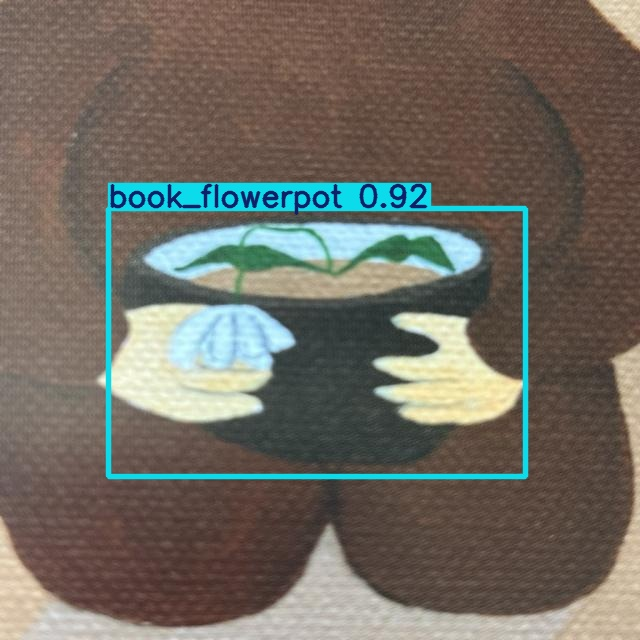

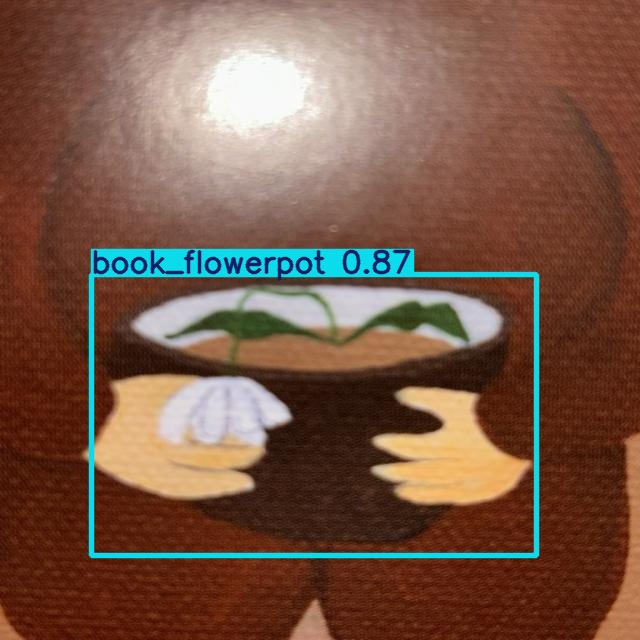

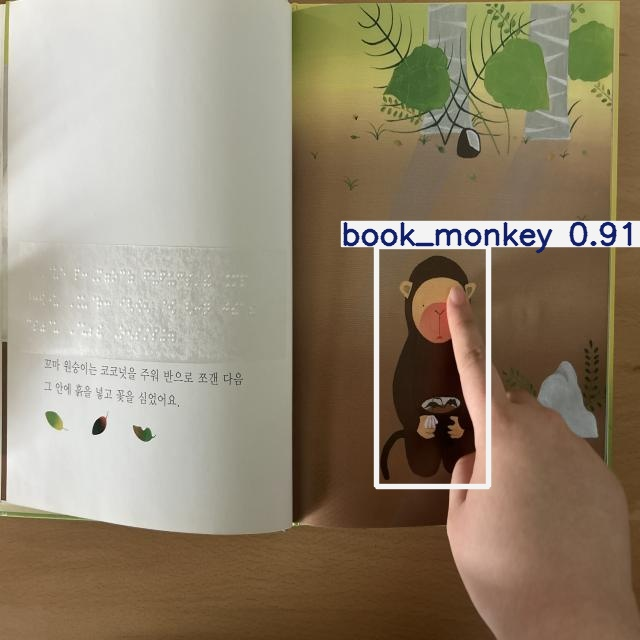

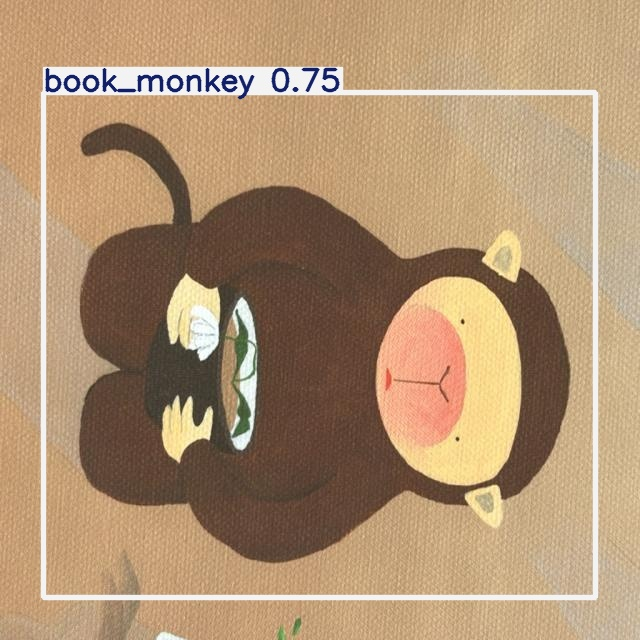

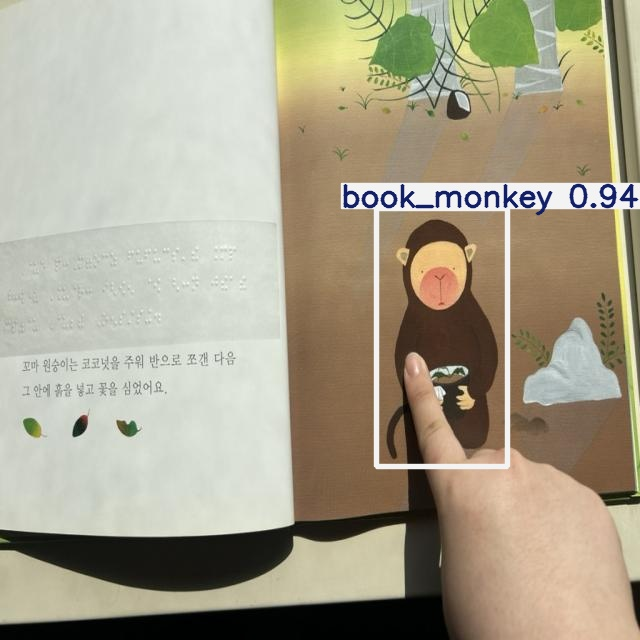

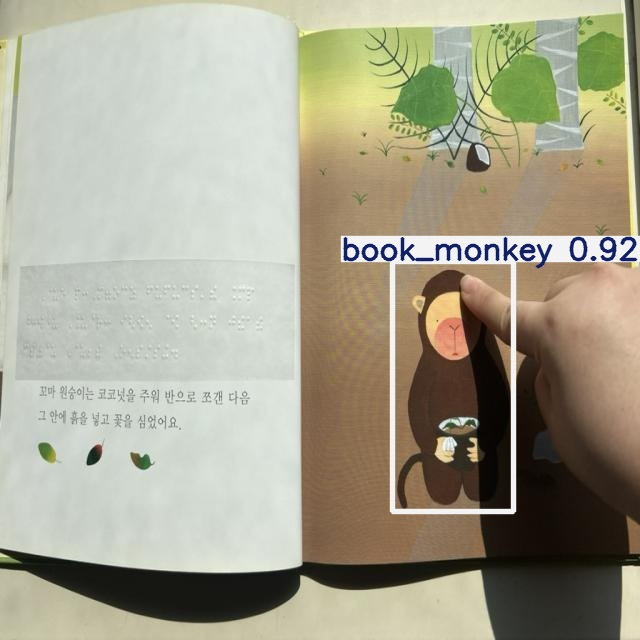

val: data=./AI-Picture-Book-Object-Detection-3/data.yaml, weights=['runs/train/picture_book_yolov5/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7037095 parameters, 0 gradients, 15.8 GFLOPs
Traceback (most recent call last):
  File "/content/yolov5/yolov5/utils/dataloaders.py", line 579, in __init__
    raise FileNotFoundError(f"{prefix}{p} does not exist")
FileNotFoundError: test: /content/yolov5/yolov5/test/images does not exist

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/content/yolov5/yolov5/val.py", line 527, in <module>
  

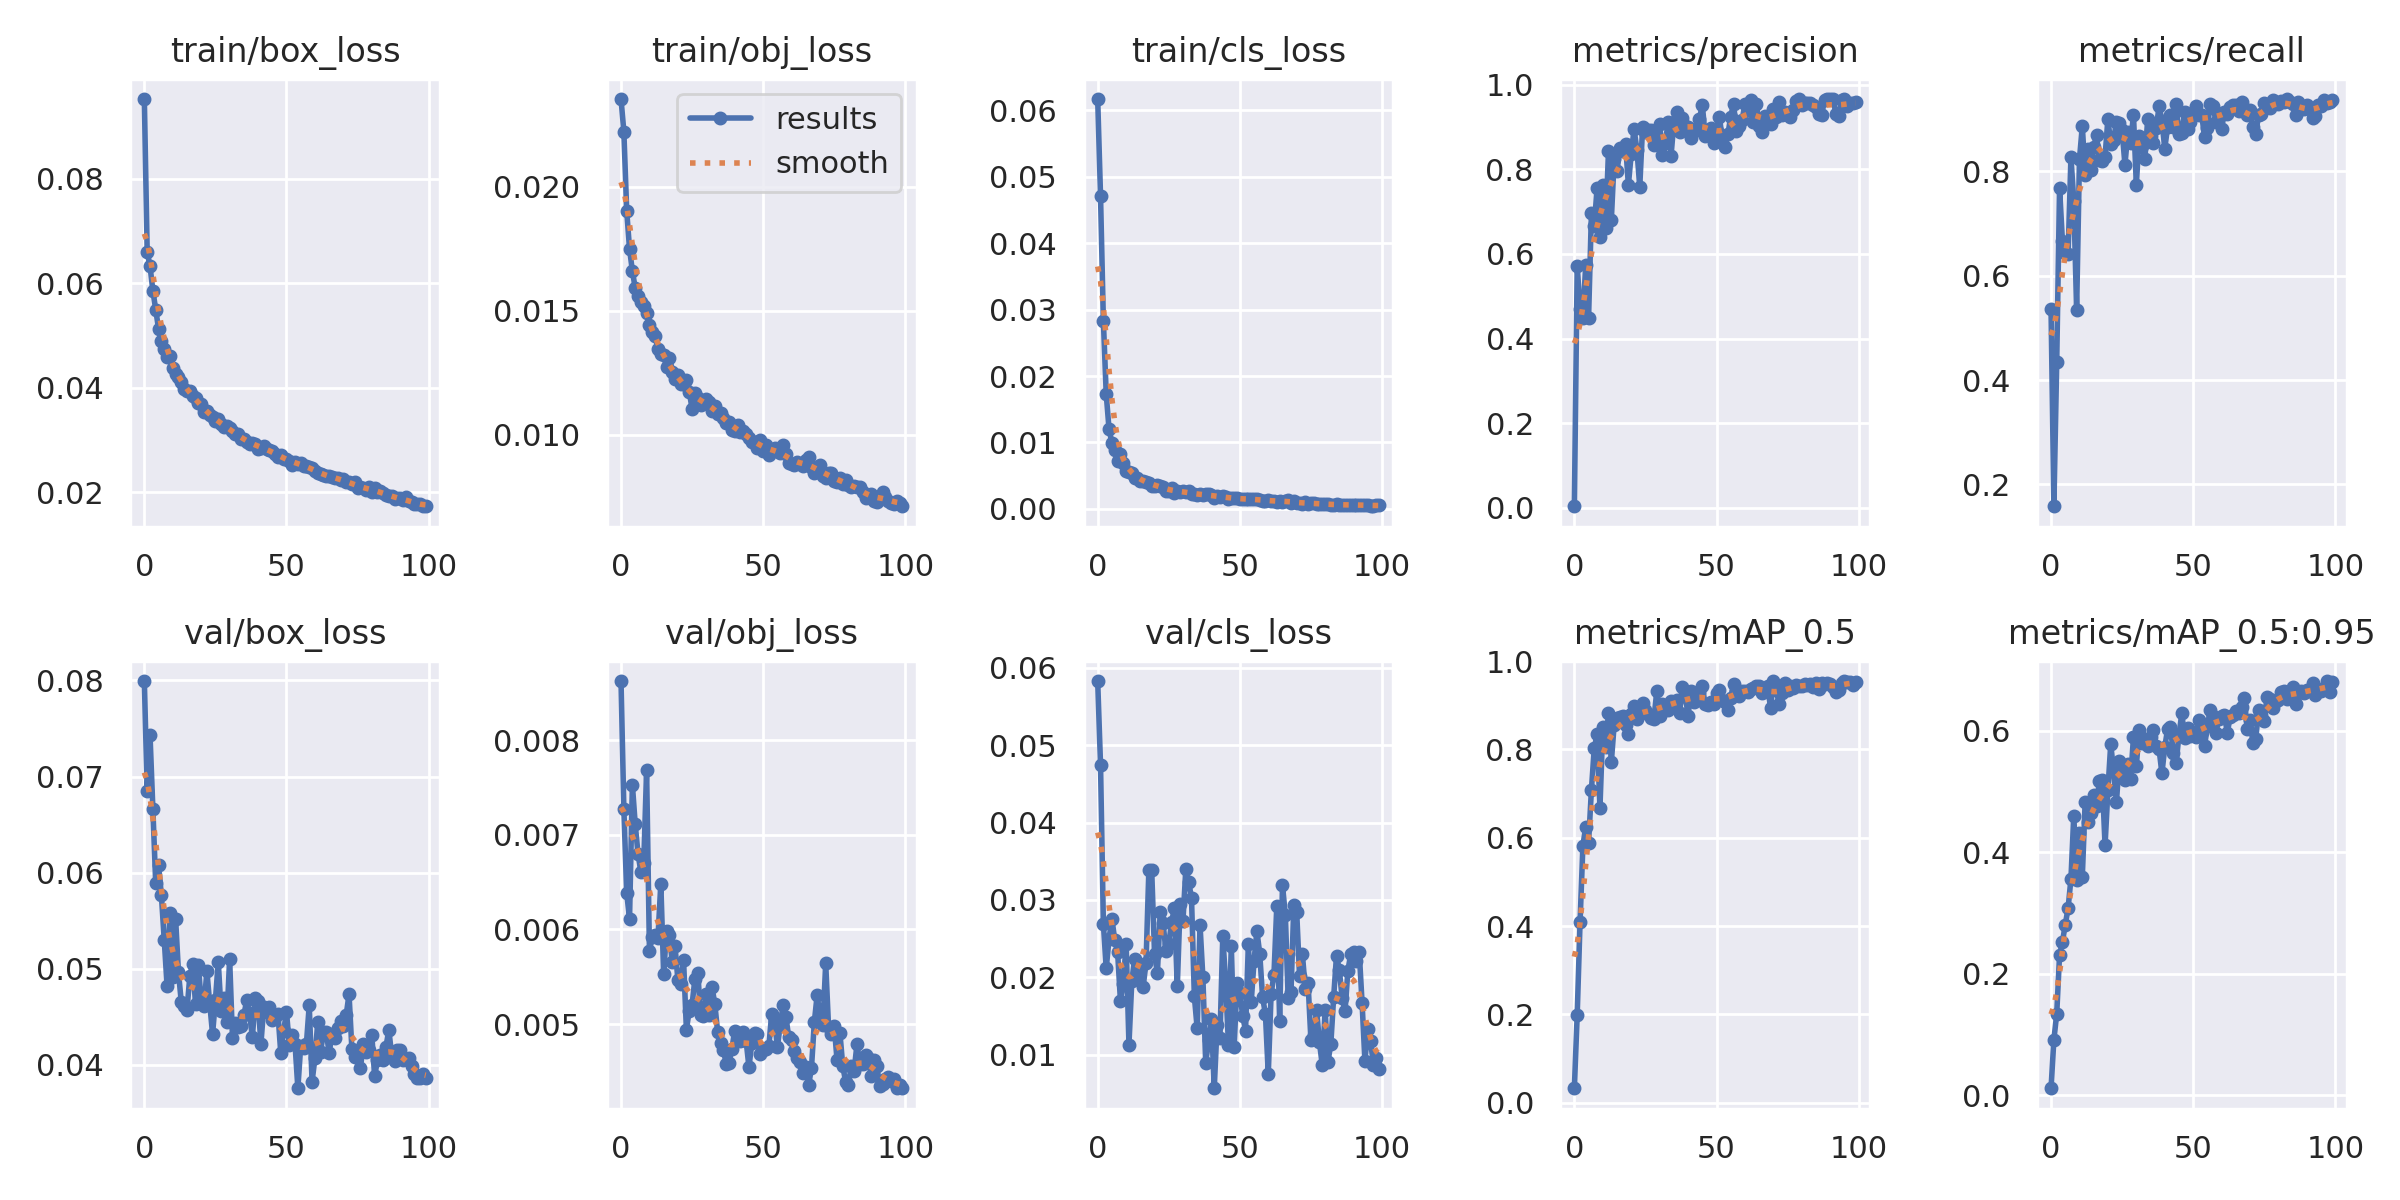

In [ ]:
import glob
from IPython.display import Image, display

# 가장 최근 학습된 best.pt 찾기
best_weights = sorted(glob.glob("runs/train/*/weights/best.pt"))[-1]
print("Best weights:", best_weights)

# 테스트 이미지 추론
!python detect.py \
--weights {best_weights} \
--conf 0.25 \
--source ./AI-Picture-Book-Object-Detection-4/test/images

# 추론 결과 확인
results = sorted(glob.glob("runs/detect/exp*/*.jpg"))

print(f"Detected Images: {len(results)}")

for img in results[:10]:
    display(Image(filename=img))

# Test Dataset 평가
!python val.py \
--weights {best_weights} \
--data ./AI-Picture-Book-Object-Detection-4/data.yaml \
--img 640 \
--task test

# 학습 결과 그래프 표시
result_imgs = sorted(glob.glob("runs/train/*/results.png"))

if result_imgs:
    print("Training Result:", result_imgs[-1])
    display(Image(filename=result_imgs[-1]))
else:
    print("results.png 파일을 찾지 못했습니다.")